# Week 3: Advanced Data Analysis and Visualization in Logistics

**Step 1: Load & Inspect Dataset**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\arkat\OneDrive\Desktop\M.tech\b.techprojects\Internship projects\Logistics Data Analyst Intern\TASK-3\week3_logistics_cleaned_dataset.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (32065, 26)


,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   timestamp                        32065 non-null  object 
 1   vehicle_gps_latitude             32065 non-null  float64
 2   vehicle_gps_longitude            32065 non-null  float64
 3   fuel_consumption_rate            32065 non-null  float64
 4   eta_variation_hours              32065 non-null  float64
 5   traffic_congestion_level         32065 non-null  float64
 6   warehouse_inventory_level        32065 non-null  float64
 7   loading_unloading_time           32065 non-null  float64
 8   handling_equipment_availability  32065 non-null  float64
 9   order_fulfillment_status         32065 non-null  float64
 10  weather_condition_severity       32065 non-null  float64
 11  port_congestion_level            32065 non-null  float64
 12  shipping_costs    

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 32065
Columns: 26


In [5]:
df.describe()

,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,...,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,delivery_time_deviation
count,32065.000000,32065.000000,32065.000000,32065.000000,3.206500e+04,3.206500e+04,32065.000000,3.206500e+04,32065.000000,3.206500e+04,...,32065.000000,32065.000000,3.206500e+04,32065.000000,32065.000000,3.206500e+04,3.206500e+04,32065.000000,32065.000000,32065.000000
mean,38.023589,-90.116648,8.011735,2.893068,4.991493e+00,2.992547e+02,2.291669,3.026954e-01,0.600740,4.976082e-01,...,6022.001286,0.044792,2.972816e-01,7.001144,2.296448,4.983913e-01,6.008723e-01,0.803656,0.699077,5.177648
std,6.917909,17.369244,4.264960,2.274044,3.532048e+00,3.234435e+02,1.554202,3.259146e-01,0.345672,3.532853e-01,...,3427.638017,14.187486,3.216115e-01,3.236328,1.555932,3.541589e-01,3.458101e-01,0.279185,0.324514,4.157988
min,30.000000,-119.999998,5.000000,-1.999993,1.091633e-09,1.322210e-12,0.500000,4.565769e-16,0.000001,4.536949e-09,...,100.002966,-10.000000,7.255415e-19,0.000050,0.500000,4.043927e-09,3.269508e-07,0.000048,0.000003,-1.999998
25%,31.280550,-106.253913,5.019984,1.185744,1.474720e+00,1.605163e+01,0.774798,1.710828e-02,0.277096,1.440135e-01,...,2822.607616,-9.931074,1.678269e-02,4.593407,0.776166,1.443567e-01,2.783148e-01,0.693739,0.456009,1.269197
50%,36.413820,-86.293414,5.636036,3.882059,4.981244e+00,1.572880e+02,1.917121,1.595151e-01,0.680553,4.961781e-01,...,6785.123209,-7.858681,1.549760e-01,8.385605,1.938273,4.988468e-01,6.831130e-01,0.958128,0.839599,6.113662
75%,44.453655,-73.079367,9.669944,4.884355,8.534902e+00,5.405980e+02,3.734188,5.535954e-01,0.938160,8.498226e-01,...,9374.252913,6.024012,5.405408e-01,9.836152,3.750817,8.510762e-01,9.372889e-01,0.998746,0.982391,9.249206
max,50.000000,-70.000000,19.999875,5.000000,9.999999e+00,9.999993e+02,5.000000,9.999995e-01,1.000000,1.000000e+00,...,10000.000000,39.999886,1.000000e+00,10.000000,5.000000,1.000000e+00,1.000000e+00,1.000000,1.000000,10.000000


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
timestamp                          0
vehicle_gps_latitude               0
vehicle_gps_longitude              0
fuel_consumption_rate              0
eta_variation_hours                0
traffic_congestion_level           0
warehouse_inventory_level          0
loading_unloading_time             0
handling_equipment_availability    0
order_fulfillment_status           0
weather_condition_severity         0
port_congestion_level              0
shipping_costs                     0
supplier_reliability_score         0
lead_time_days                     0
historical_demand                  0
iot_temperature                    0
cargo_condition_status             0
route_risk_level                   0
customs_clearance_time             0
driver_behavior_score              0
fatigue_monitoring_score           0
disruption_likelihood_score        0
delay_probability                  0
risk_classification                0
delivery_time_deviation            0
dtype: int64


In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

print(df["timestamp"].min())
print(df["timestamp"].max())

2021-01-01 00:00:00
2024-08-29 00:00:00


In [9]:
df["date"] = df["timestamp"].dt.date
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day_name()

**Step 2 --Exploratory Data Analysis (EDA)**

In [10]:
# Numerical columns summary
numeric_summary = df.describe().T

display(numeric_summary)

,count,mean,min,25%,50%,75%,max,std
timestamp,32065,2022-10-31 00:00:00.000000256,2021-01-01 00:00:00,2021-12-01 00:00:00,2022-10-31 00:00:00,2023-09-30 00:00:00,2024-08-29 00:00:00,NaN
vehicle_gps_latitude,32065.0,38.023589,30.0,31.28055,36.41382,44.453655,50.0,6.917909
vehicle_gps_longitude,32065.0,-90.116648,-119.999998,-106.253913,-86.293414,-73.079367,-70.0,17.369244
fuel_consumption_rate,32065.0,8.011735,5.0,5.019984,5.636036,9.669944,19.999875,4.26496
eta_variation_hours,32065.0,2.893068,-1.999993,1.185744,3.882059,4.884355,5.0,2.274044
traffic_congestion_level,32065.0,4.991493,0.0,1.47472,4.981244,8.534902,9.999999,3.532048
warehouse_inventory_level,32065.0,299.254732,0.0,16.051635,157.288022,540.597991,999.999298,323.443513
loading_unloading_time,32065.0,2.291669,0.5,0.774798,1.917121,3.734188,5.0,1.554202
handling_equipment_availability,32065.0,0.302695,0.0,0.017108,0.159515,0.553595,0.999999,0.325915
order_fulfillment_status,32065.0,0.60074,0.000001,0.277096,0.680553,0.93816,1.0,0.345672


In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(list(numeric_cols))


Numerical Columns:
['vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'order_fulfillment_status', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'delay_probability', 'delivery_time_deviation', 'hour']


In [12]:
# Mean, median and standard deviation
central_tendency = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Std_Dev": df[numeric_cols].std()
})

display(central_tendency)

,Mean,Median,Std_Dev
vehicle_gps_latitude,38.023589,36.413820,6.917909
vehicle_gps_longitude,-90.116648,-86.293414,17.369244
fuel_consumption_rate,8.011735,5.636036,4.264960
eta_variation_hours,2.893068,3.882059,2.274044
traffic_congestion_level,4.991493,4.981244,3.532048
warehouse_inventory_level,299.254732,157.288022,323.443513
loading_unloading_time,2.291669,1.917121,1.554202
handling_equipment_availability,0.302695,0.159515,0.325915
order_fulfillment_status,0.600740,0.680553,0.345672
weather_condition_severity,0.497608,0.496178,0.353285


**Step 3 --Actual dataset columns**

In [14]:
# Get numerical columns from the dataset
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
print(numeric_cols)

Numerical columns:
['vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'order_fulfillment_status', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'delay_probability', 'delivery_time_deviation', 'hour']


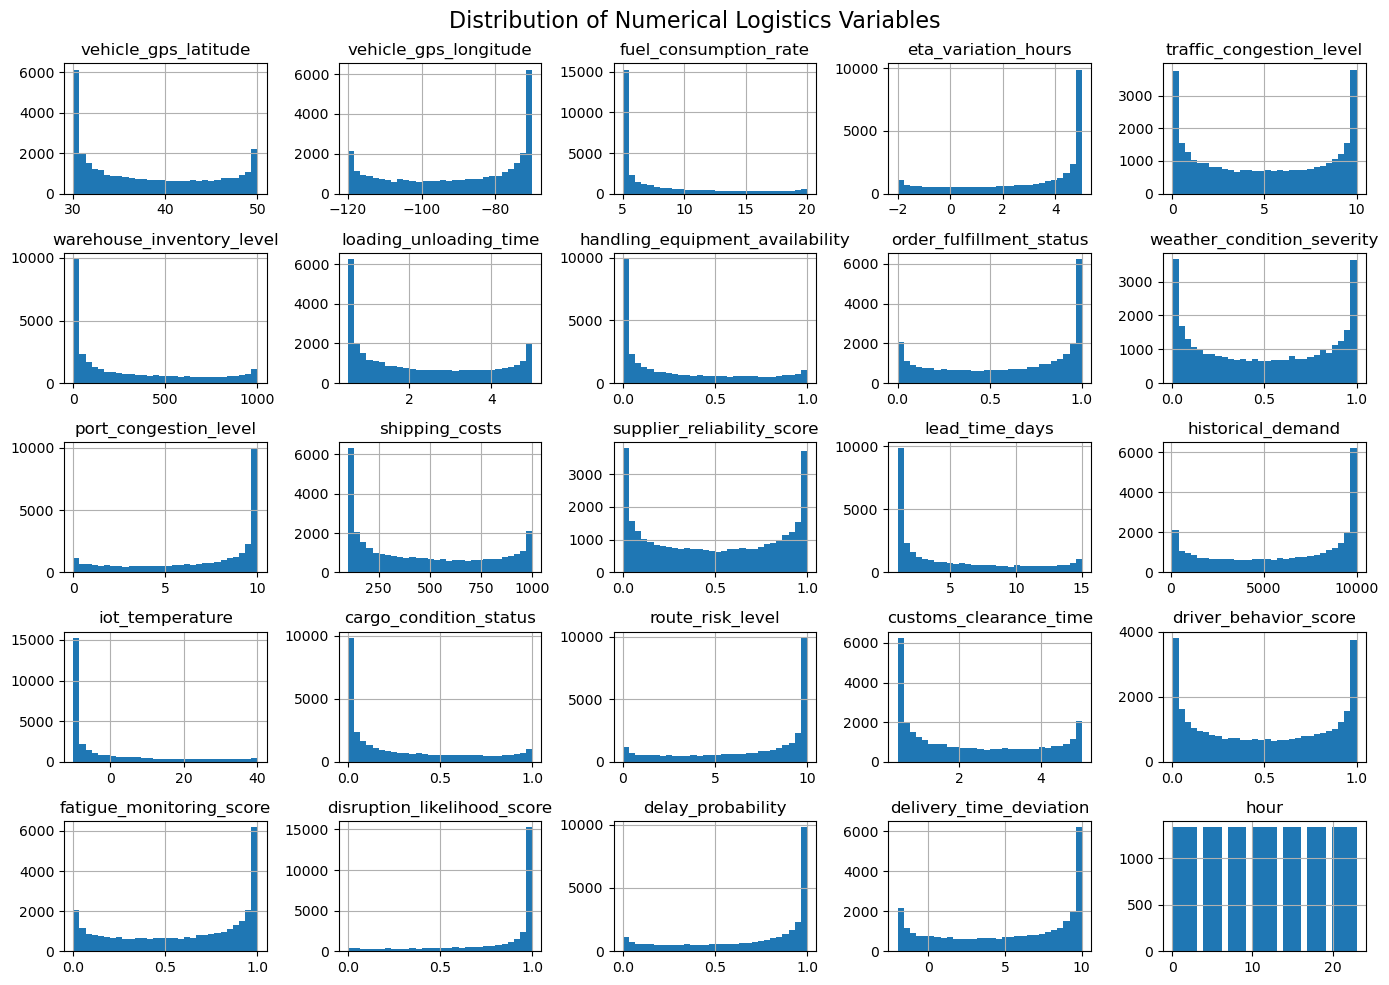

In [15]:
# Distribution of numerical variables

df[numeric_cols].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distribution of Numerical Logistics Variables", fontsize=16)
plt.tight_layout()
plt.show()

In [16]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
['risk_classification', 'date', 'day']


In [17]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))


risk_classification
risk_classification
High Risk        23944
Moderate Risk     5011
Low Risk          3110
Name: count, dtype: int64

date
date
2021-01-01    24
2023-06-18    24
2023-06-16    24
2023-06-15    24
2023-06-14    24
2023-06-13    24
2023-06-12    24
2023-06-11    24
2023-06-10    24
2023-06-09    24
Name: count, dtype: int64

day
day
Friday       4584
Saturday     4584
Sunday       4584
Monday       4584
Tuesday      4584
Wednesday    4584
Thursday     4561
Name: count, dtype: int64


In [18]:
print(df.columns.tolist())

['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'order_fulfillment_status', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'delay_probability', 'risk_classification', 'delivery_time_deviation', 'date', 'hour', 'day']


In [19]:
print(df.shape)

(32065, 29)


In [20]:
print(df.dtypes)

timestamp                          datetime64[ns]
vehicle_gps_latitude                      float64
vehicle_gps_longitude                     float64
fuel_consumption_rate                     float64
eta_variation_hours                       float64
traffic_congestion_level                  float64
warehouse_inventory_level                 float64
loading_unloading_time                    float64
handling_equipment_availability           float64
order_fulfillment_status                  float64
weather_condition_severity                float64
port_congestion_level                     float64
shipping_costs                            float64
supplier_reliability_score                float64
lead_time_days                            float64
historical_demand                         float64
iot_temperature                           float64
cargo_condition_status                    float64
route_risk_level                          float64
customs_clearance_time                    float64


**Step 4 -- Correlation Analysis**

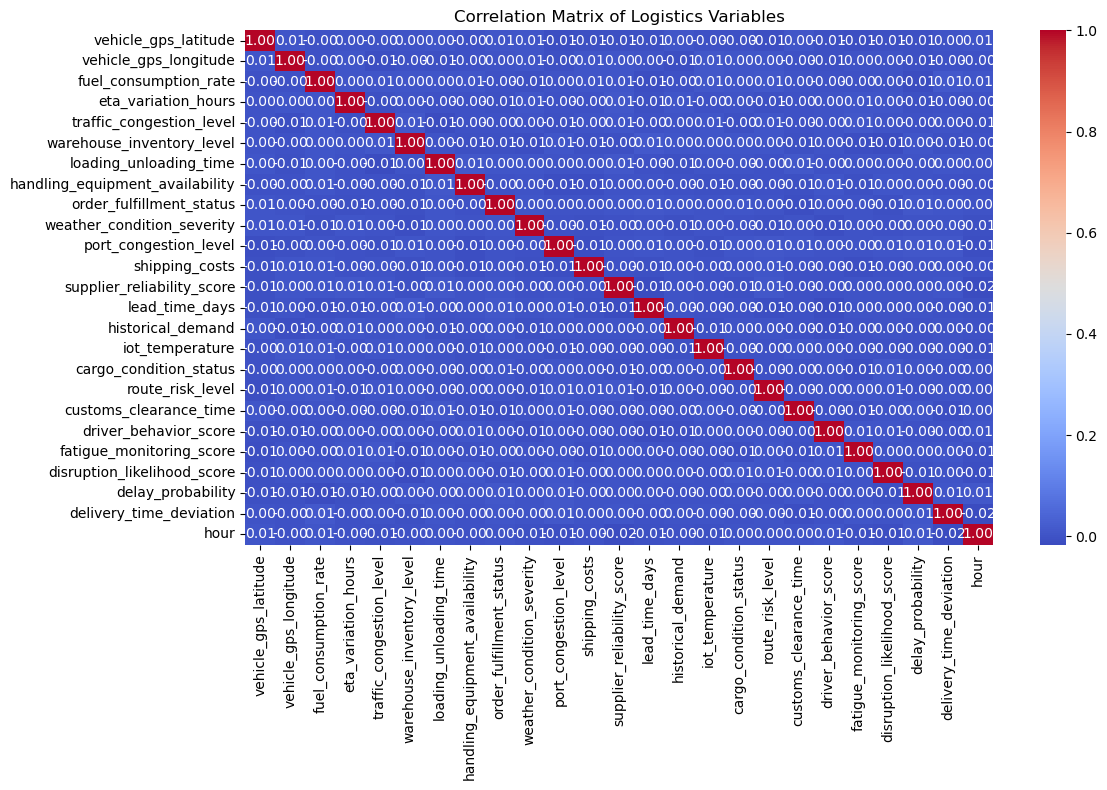

In [21]:
# Correlation matrix for numerical variables

correlation = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Logistics Variables")
plt.tight_layout()
plt.show()

In [22]:
# Find strongest correlations

corr_pairs = (
    correlation
    .where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

display(corr_pairs.head(10))

delivery_time_deviation     hour                          -0.016593
supplier_reliability_score  hour                          -0.016219
traffic_congestion_level    loading_unloading_time        -0.014678
lead_time_days              driver_behavior_score         -0.014183
fuel_consumption_rate       delay_probability             -0.013655
warehouse_inventory_level   disruption_likelihood_score   -0.013536
supplier_reliability_score  lead_time_days                -0.013048
fuel_consumption_rate       lead_time_days                -0.012604
                            delivery_time_deviation        0.012495
vehicle_gps_latitude        route_risk_level              -0.012222
dtype: float64

In [23]:
# Display top categories for each categorical variable

for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(df[col].value_counts().head(10))


--- risk_classification ---


risk_classification
High Risk        23944
Moderate Risk     5011
Low Risk          3110
Name: count, dtype: int64


--- date ---


date
2021-01-01    24
2023-06-18    24
2023-06-16    24
2023-06-15    24
2023-06-14    24
2023-06-13    24
2023-06-12    24
2023-06-11    24
2023-06-10    24
2023-06-09    24
Name: count, dtype: int64


--- day ---


day
Friday       4584
Saturday     4584
Sunday       4584
Monday       4584
Tuesday      4584
Wednesday    4584
Thursday     4561
Name: count, dtype: int64

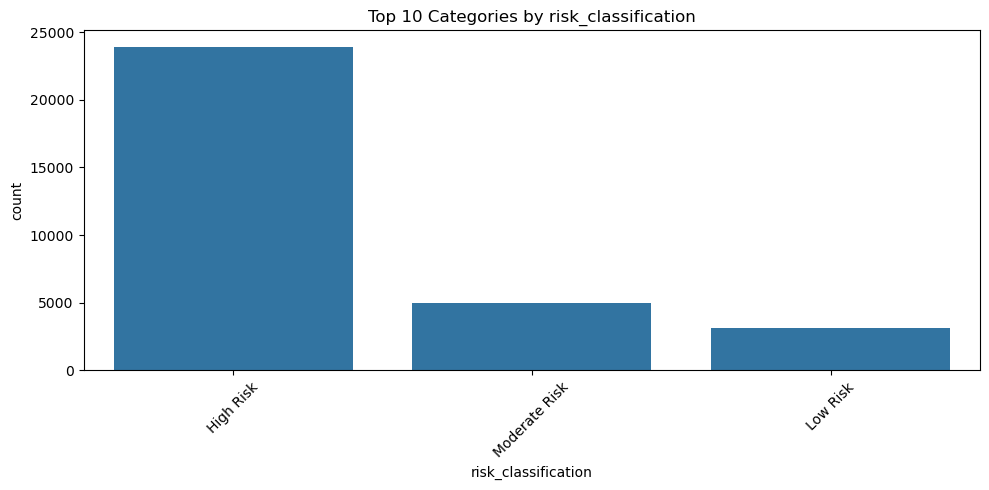

In [24]:
# Distribution of the first categorical variable

col = categorical_cols[0]

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x=col,
    order=df[col].value_counts().head(10).index
)

plt.title(f"Top 10 Categories by {col}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

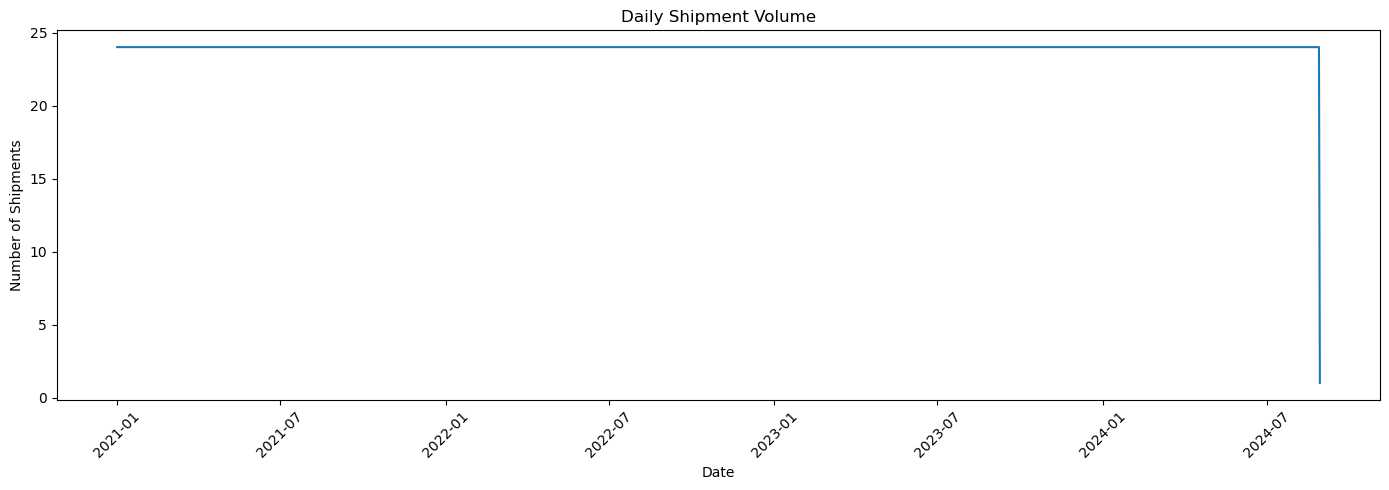

In [25]:
# Daily shipment volume

daily_shipments = df.groupby("date").size()

plt.figure(figsize=(14, 5))
plt.plot(daily_shipments.index, daily_shipments.values)

plt.title("Daily Shipment Volume")
plt.xlabel("Date")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
total_shipments = len(df)

print("Total Shipments:", total_shipments)

Total Shipments: 32065


In [27]:
print(categorical_cols)

['risk_classification', 'date', 'day']


**Step 5 -- Shipment Performance Analysis**

In [29]:
print(df.columns.tolist())

['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'order_fulfillment_status', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'delay_probability', 'risk_classification', 'delivery_time_deviation', 'date', 'hour', 'day']


In [30]:
# Find logistics performance-related columns

keywords = [
    "delivery", "delay", "status",
    "on_time", "late", "cost",
    "distance", "weight", "volume"
]

relevant_cols = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in keywords)
]

print("Relevant logistics columns:")
print(relevant_cols)

Relevant logistics columns:
['order_fulfillment_status', 'shipping_costs', 'cargo_condition_status', 'delay_probability', 'delivery_time_deviation']


In [31]:
status_col = None

for col in df.columns:
    if any(word in col.lower() for word in ["status", "delivery_status", "on_time"]):
        status_col = col
        break

print("Status column:", status_col)

Status column: order_fulfillment_status


Dataset Shape: (32065, 26)

Numerical Columns:
['vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'order_fulfillment_status', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'delay_probability', 'delivery_time_deviation']

Strongest Correlation:
traffic_congestion_level vs loading_unloading_time
Correlation Value: -0.01


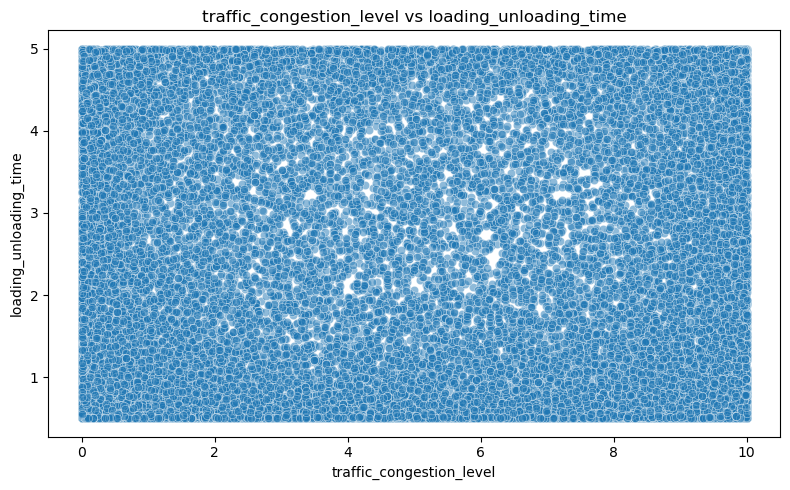

In [5]:
# STEP 14 — Load dataset and perform relationship analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv(r"C:\Users\arkat\OneDrive\Desktop\M.tech\b.techprojects\Internship projects\Logistics Data Analyst Intern\TASK-3\week3_logistics_cleaned_dataset.csv")

# Convert timestamp if available
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Find numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Dataset Shape:", df.shape)
print("\nNumerical Columns:")
print(numeric_cols)

# Correlation matrix
correlation = df[numeric_cols].corr()

# Find strongest correlation pair
corr_pairs = (
    correlation
    .where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

strongest_pair = corr_pairs.index[0]

x_col = strongest_pair[0]
y_col = strongest_pair[1]

print("\nStrongest Correlation:")
print(f"{x_col} vs {y_col}")
print(f"Correlation Value: {corr_pairs.iloc[0]:.2f}")

# Scatter plot
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x=x_col,
    y=y_col,
    alpha=0.5
)

plt.title(f"{x_col} vs {y_col}")
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.tight_layout()
plt.show()

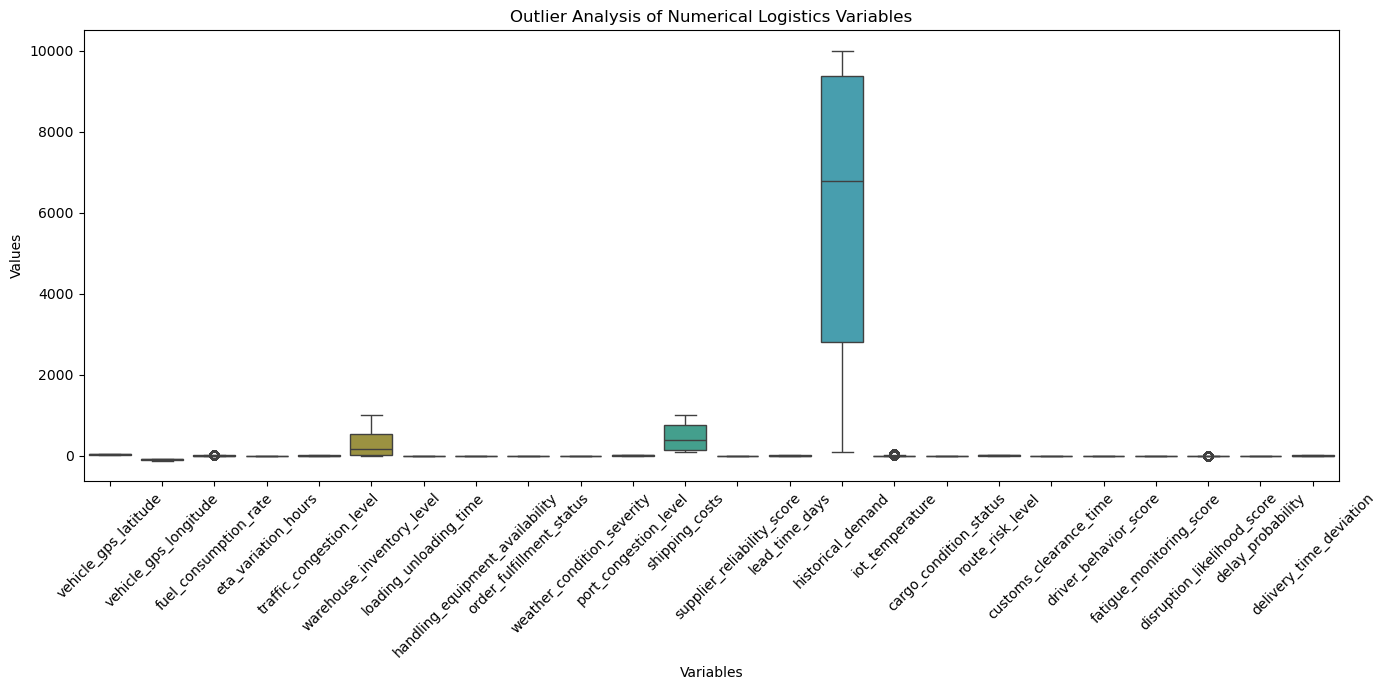

In [9]:
# Step 15 —Outlier Analysis
plt.figure(figsize=(14, 7))

sns.boxplot(data=df[numeric_cols])

plt.title("Outlier Analysis of Numerical Logistics Variables")
plt.xlabel("Variables")
plt.ylabel("Values")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [10]:
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary[col] = outliers

outlier_summary = pd.Series(outlier_summary).sort_values(ascending=False)

display(outlier_summary)

fuel_consumption_rate              2536
disruption_likelihood_score        2494
iot_temperature                    2301
vehicle_gps_latitude                  0
lead_time_days                        0
delay_probability                     0
fatigue_monitoring_score              0
driver_behavior_score                 0
customs_clearance_time                0
route_risk_level                      0
cargo_condition_status                0
historical_demand                     0
supplier_reliability_score            0
vehicle_gps_longitude                 0
shipping_costs                        0
port_congestion_level                 0
weather_condition_severity            0
order_fulfillment_status              0
handling_equipment_availability       0
loading_unloading_time                0
warehouse_inventory_level             0
traffic_congestion_level              0
eta_variation_hours                   0
delivery_time_deviation               0
dtype: int64

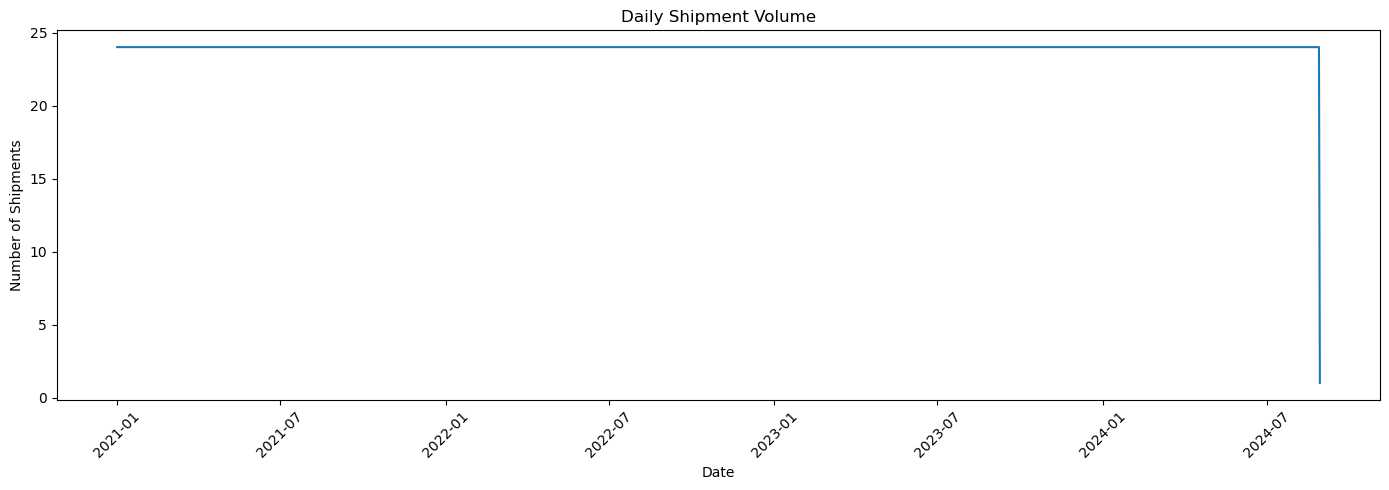

In [11]:
# Step 16 — Daily Shipment Volume

df["date"] = pd.to_datetime(df["timestamp"]).dt.date

daily_shipments = df.groupby("date").size()

plt.figure(figsize=(14, 5))

plt.plot(daily_shipments.index, daily_shipments.values)

plt.title("Daily Shipment Volume")
plt.xlabel("Date")
plt.ylabel("Number of Shipments")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
print("Average Daily Shipments:", round(daily_shipments.mean(), 2))
print("Maximum Daily Shipments:", daily_shipments.max())
print("Minimum Daily Shipments:", daily_shipments.min())

Average Daily Shipments: 23.98
Maximum Daily Shipments: 24
Minimum Daily Shipments: 1


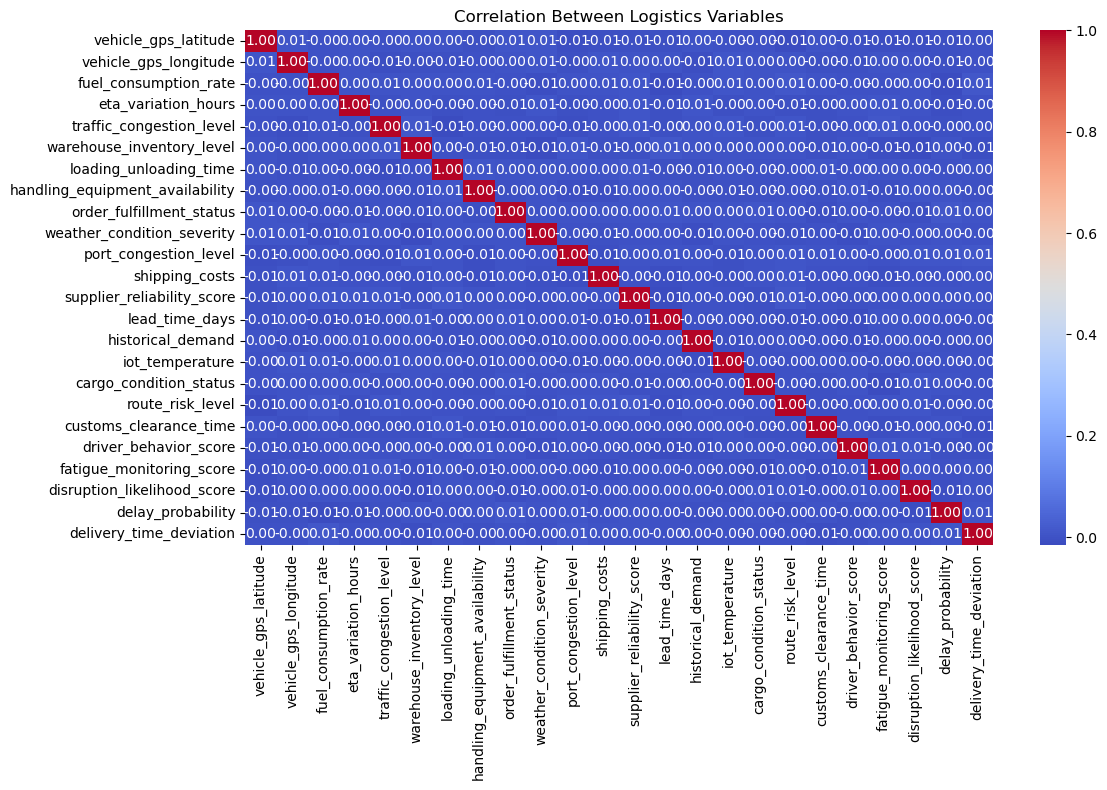

In [13]:
# Step 17 — Correlation Heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Logistics Variables")
plt.tight_layout()
plt.show()

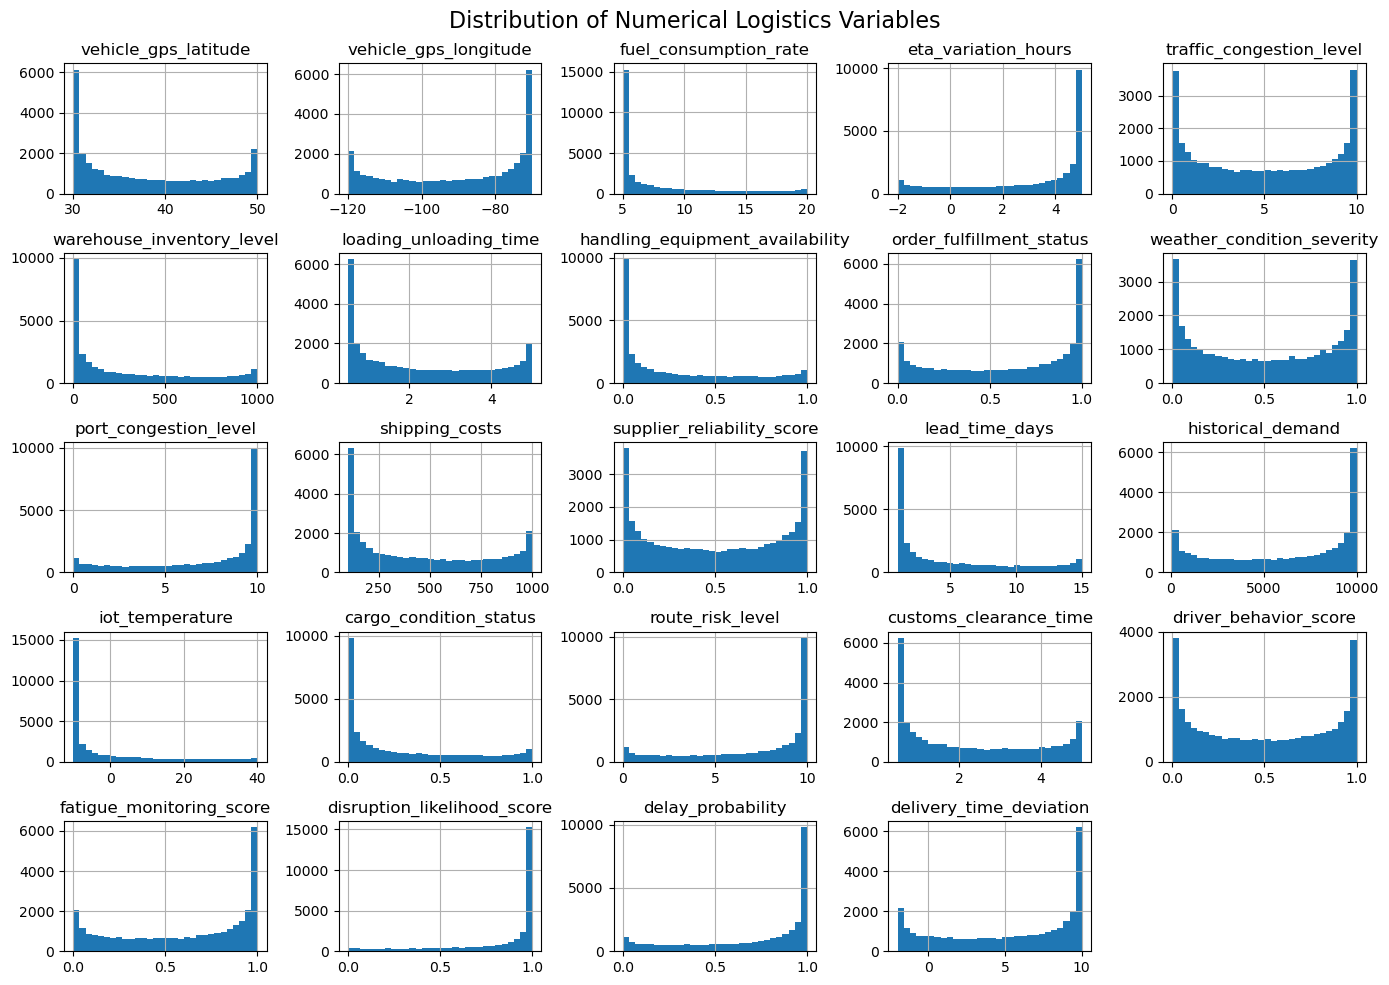

In [14]:
# Distribution of Numerical Variables
# Visualization 1 — Numerical Distributions

df[numeric_cols].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distribution of Numerical Logistics Variables", fontsize=16)
plt.tight_layout()
plt.show()

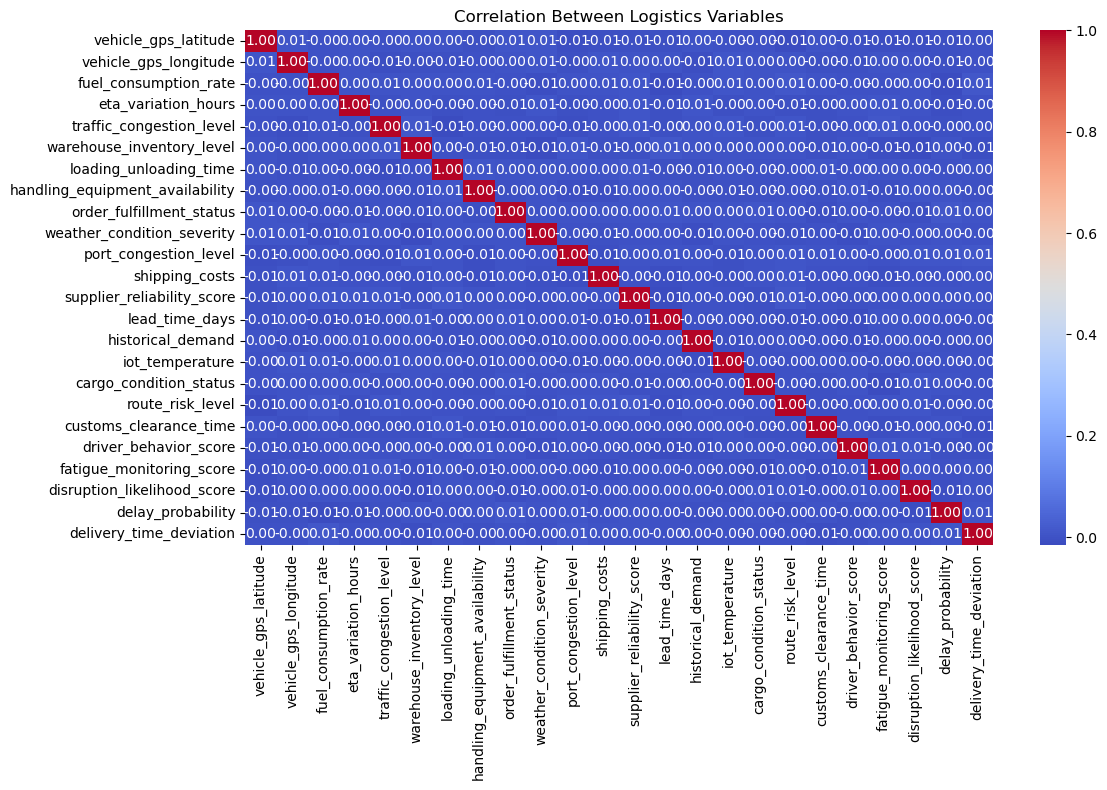

In [15]:
# Visualization 2 — Correlation Heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Logistics Variables")
plt.tight_layout()
plt.show()

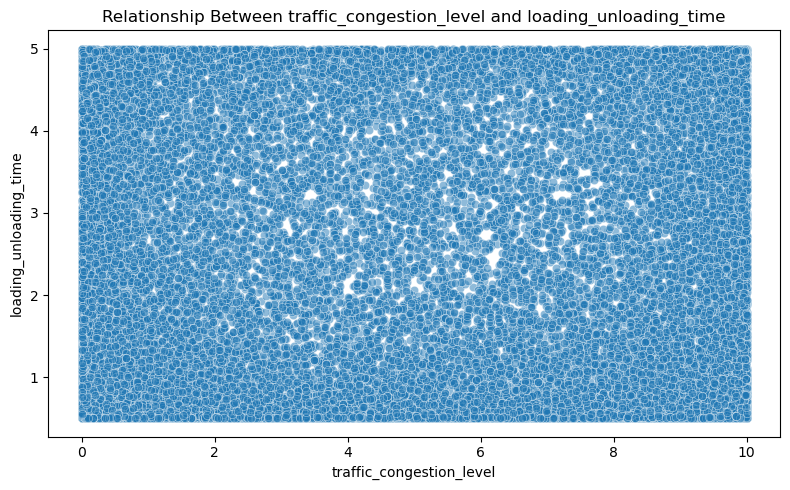

In [16]:
# Visualization 3 — Strongest Numerical Relationship

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x=x_col,
    y=y_col,
    alpha=0.5
)

plt.title(f"Relationship Between {x_col} and {y_col}")
plt.xlabel(x_col)
plt.ylabel(y_col)

plt.tight_layout()
plt.show()

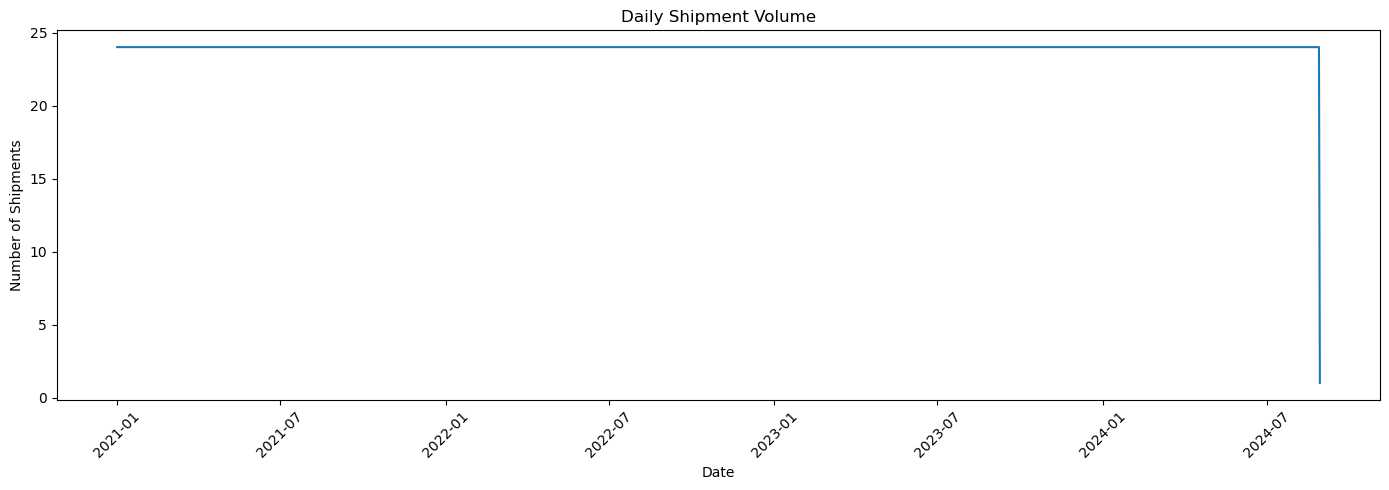

In [17]:
# Visualization 4 — Shipment Trend

plt.figure(figsize=(14, 5))

plt.plot(
    daily_shipments.index,
    daily_shipments.values
)

plt.title("Daily Shipment Volume")
plt.xlabel("Date")
plt.ylabel("Number of Shipments")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

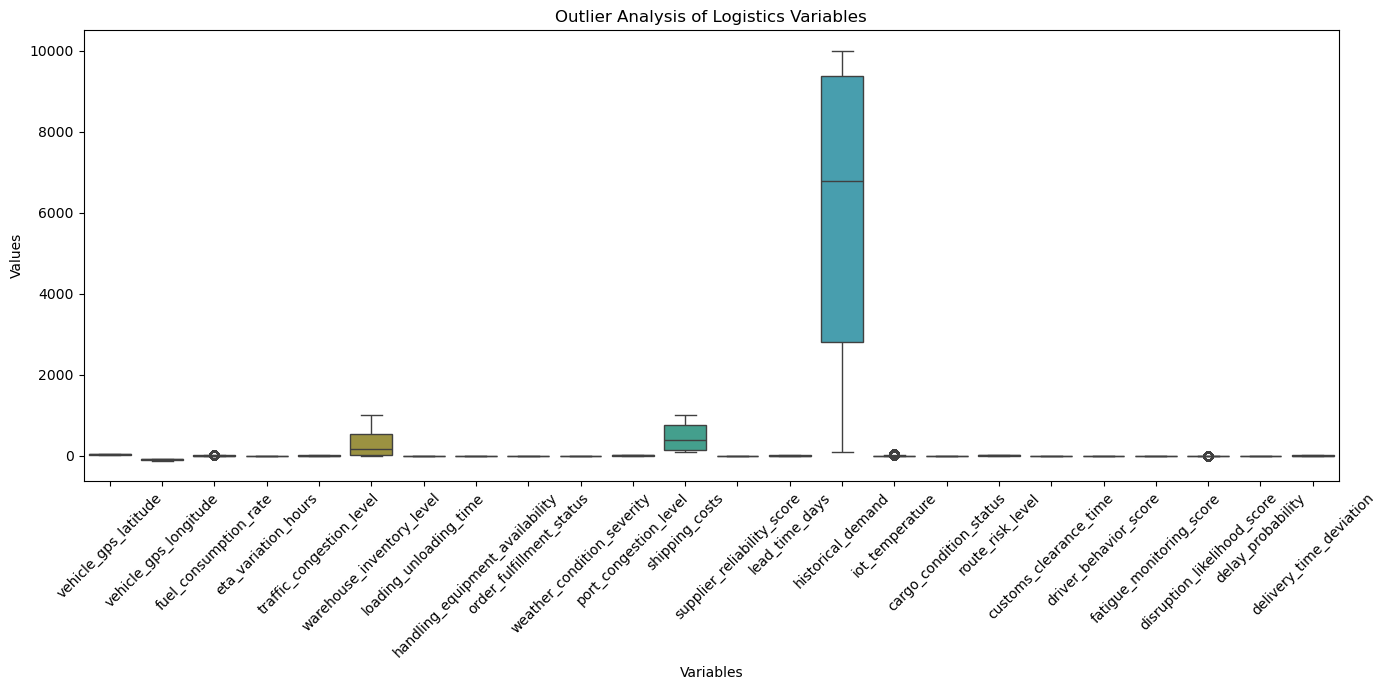

In [18]:
# Visualization 5 — Outlier Analysis

plt.figure(figsize=(14, 7))

sns.boxplot(data=df[numeric_cols])

plt.title("Outlier Analysis of Logistics Variables")
plt.xlabel("Variables")
plt.ylabel("Values")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# Step 21 — Key Statistics Table

results = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Minimum": df[numeric_cols].min(),
    "Maximum": df[numeric_cols].max(),
    "Std_Dev": df[numeric_cols].std()
})

display(results.round(2))

,Mean,Median,Minimum,Maximum,Std_Dev
vehicle_gps_latitude,38.02,36.41,30.0,50.0,6.92
vehicle_gps_longitude,-90.12,-86.29,-120.0,-70.0,17.37
fuel_consumption_rate,8.01,5.64,5.0,20.0,4.26
eta_variation_hours,2.89,3.88,-2.0,5.0,2.27
traffic_congestion_level,4.99,4.98,0.0,10.0,3.53
warehouse_inventory_level,299.25,157.29,0.0,1000.0,323.44
loading_unloading_time,2.29,1.92,0.5,5.0,1.55
handling_equipment_availability,0.30,0.16,0.0,1.0,0.33
order_fulfillment_status,0.60,0.68,0.0,1.0,0.35
weather_condition_severity,0.50,0.50,0.0,1.0,0.35


In [20]:
print("Top 10 Correlations:")
display(corr_pairs.head(10).to_frame("Correlation"))

Top 10 Correlations:


Correlation
traffic_congestion_level   loading_unloading_time         -0.014678
lead_time_days             driver_behavior_score          -0.014183
fuel_consumption_rate      delay_probability              -0.013655
warehouse_inventory_level  disruption_likelihood_score    -0.013536
supplier_reliability_score lead_time_days                 -0.013048
fuel_consumption_rate      lead_time_days                 -0.012604
                           delivery_time_deviation         0.012495
vehicle_gps_latitude       route_risk_level               -0.012222
warehouse_inventory_level  weather_condition_severity     -0.011976
                           lead_time_days                  0.011781

In [21]:
print("Total Shipments:", len(df))
print("Average Daily Shipments:", round(daily_shipments.mean(), 2))
print("Maximum Daily Shipments:", daily_shipments.max())
print("Minimum Daily Shipments:", daily_shipments.min())

Total Shipments: 32065
Average Daily Shipments: 23.98
Maximum Daily Shipments: 24
Minimum Daily Shipments: 1


In [22]:
# Step 23 — Final Analysis Summary

summary = {
    "Total Shipments": len(df),
    "Number of Variables": len(df.columns),
    "Average Daily Shipments": round(daily_shipments.mean(), 2),
    "Maximum Daily Shipments": int(daily_shipments.max()),
    "Minimum Daily Shipments": int(daily_shipments.min()),
    "Strongest Correlation": f"{x_col} vs {y_col}",
    "Correlation Value": round(corr_pairs.iloc[0], 2)
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

display(summary_df)

,Metric,Value
0,Total Shipments,32065
1,Number of Variables,27
2,Average Daily Shipments,23.98
3,Maximum Daily Shipments,24
4,Minimum Daily Shipments,1
5,Strongest Correlation,traffic_congestion_level vs loading_unloading_...
6,Correlation Value,-0.01
